In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
df = pd.read_csv(r"D:\sem 5\ML\review\Team13_ML\data\garments_worker_productivity.csv")
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1197, 15)


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [9]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nBasic Statistics:")
display(df.describe())

Column Names:
['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']

Data Types:


date                         str
quarter                      str
department                   str
day                          str
team                       int64
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                  int64
incentive                  int64
idle_time                float64
idle_men                   int64
no_of_style_change         int64
no_of_workers            float64
actual_productivity      float64
dtype: object


Missing Values:


date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64


Duplicate Rows: 0

Basic Statistics:


,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


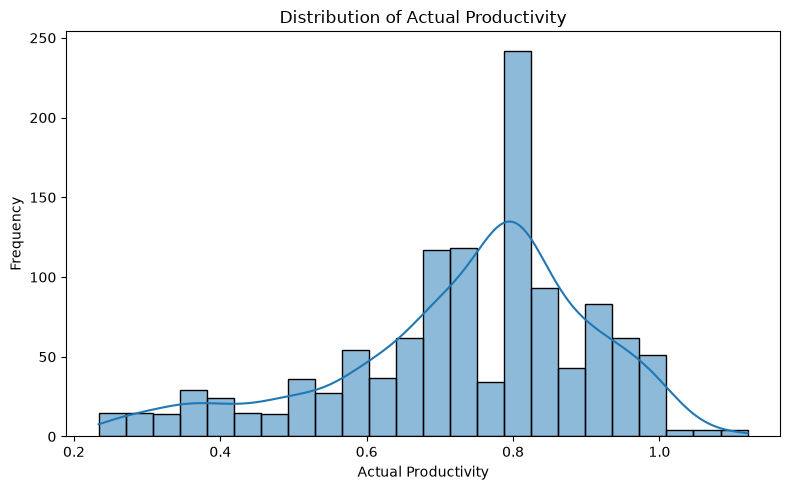

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["actual_productivity"],
    kde=True
)

plt.title("Distribution of Actual Productivity")
plt.xlabel("Actual Productivity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

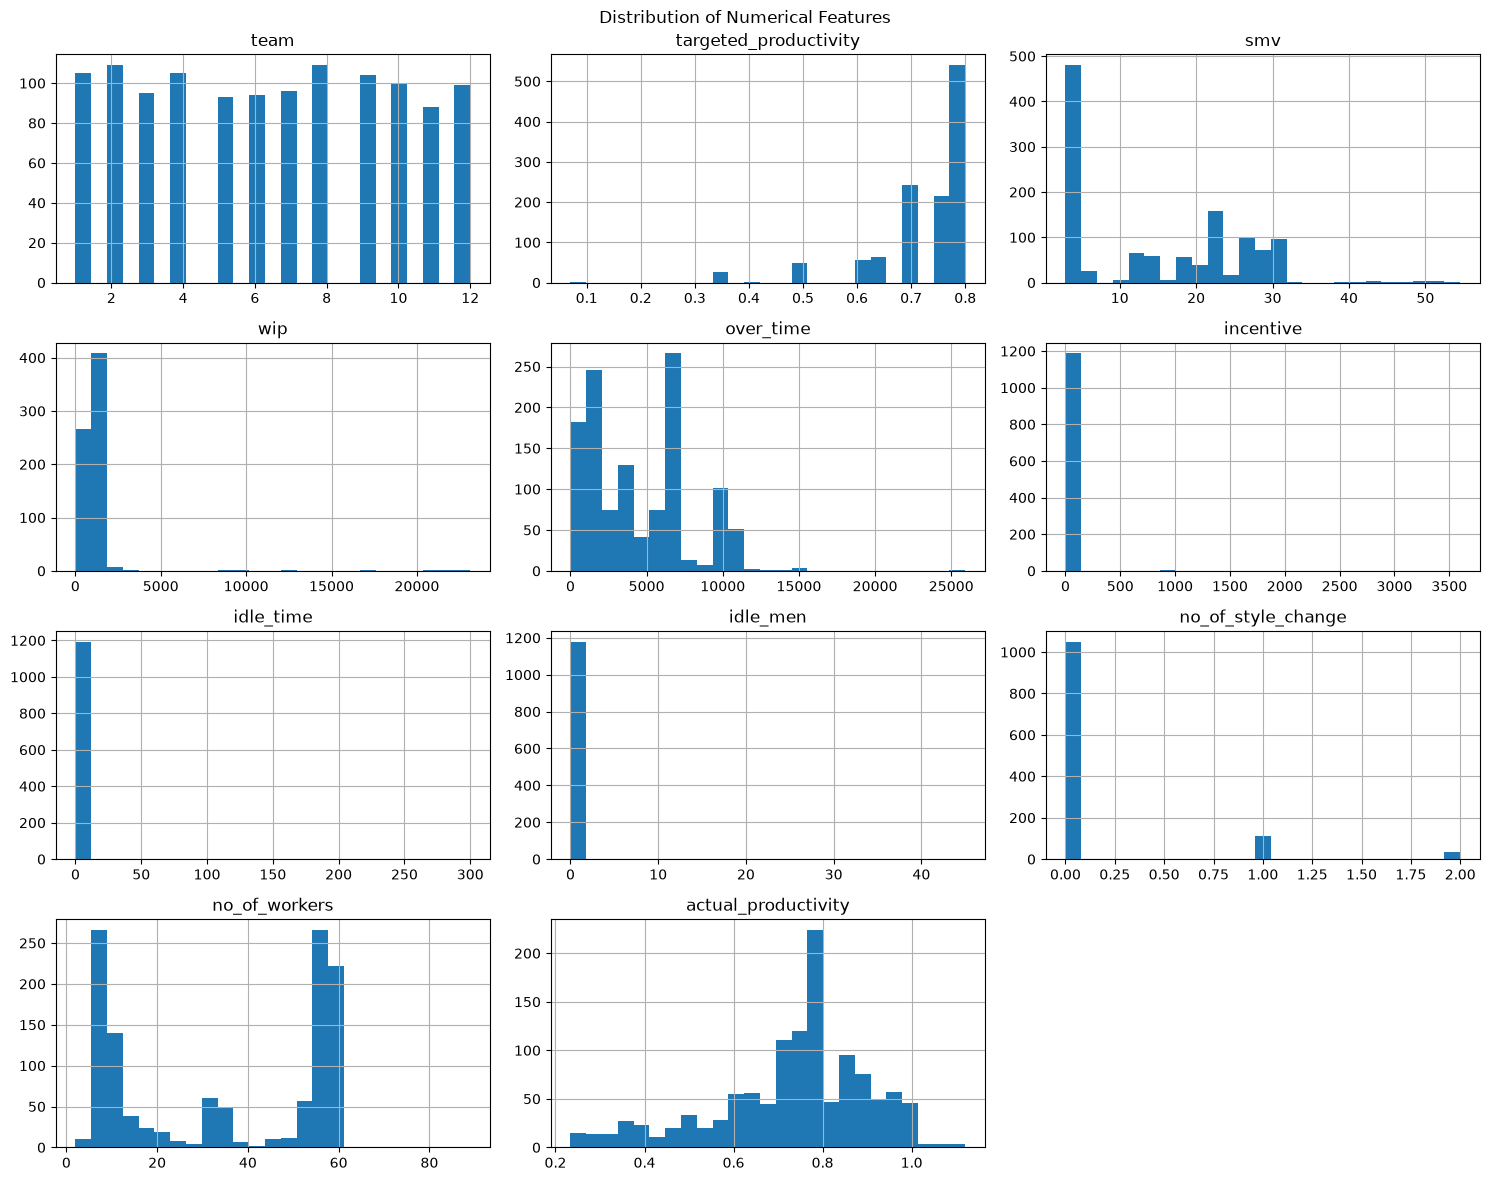

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(15, 12),
    bins=25
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()


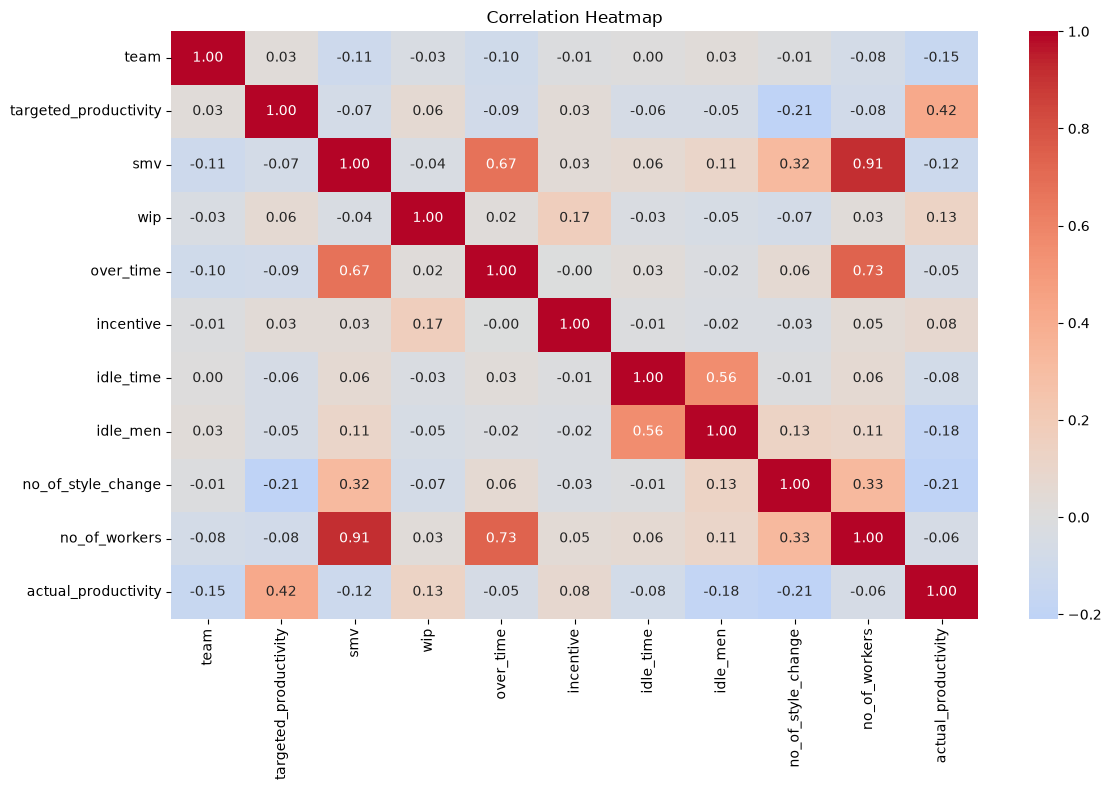

In [12]:
plt.figure(figsize=(12, 8))

correlation = df[numeric_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

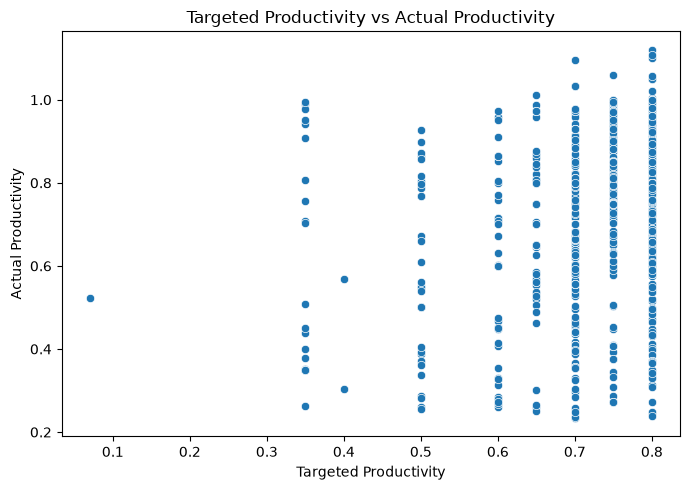

In [13]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="targeted_productivity",
    y="actual_productivity"
)

plt.title("Targeted Productivity vs Actual Productivity")
plt.xlabel("Targeted Productivity")
plt.ylabel("Actual Productivity")
plt.tight_layout()
plt.show()

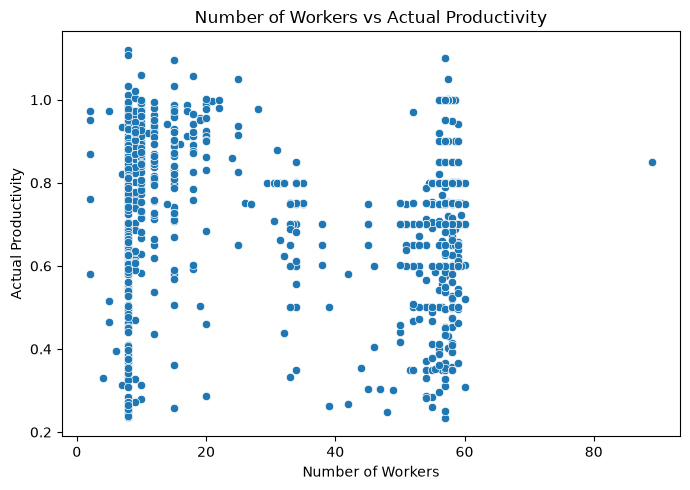

In [14]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="no_of_workers",
    y="actual_productivity"
)

plt.title("Number of Workers vs Actual Productivity")
plt.xlabel("Number of Workers")
plt.ylabel("Actual Productivity")
plt.tight_layout()
plt.show()

In [15]:
missing = df.isnull().sum()

print("Columns with missing values:")
display(missing[missing > 0])

Columns with missing values:


wip    506
dtype: int64

In [16]:
df_clean = df.copy()

# Numerical columns
numeric_features = df_clean.select_dtypes(include=np.number).columns.tolist()

# Remove target from feature list
numeric_features.remove("actual_productivity")

# Fill numerical missing values with median
for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Categorical columns
categorical_features = df_clean.select_dtypes(include="object").columns.tolist()

# Fill categorical missing values with mode
for col in categorical_features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Remaining missing values:", df_clean.isnull().sum().sum())

Remaining missing values: 0


C:\Users\krish\AppData\Local\Temp\ipykernel_26092\1642897416.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df_clean.select_dtypes(include="object").columns.tolist()


In [17]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates()

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 1197
Rows after: 1197
Duplicates removed: 0


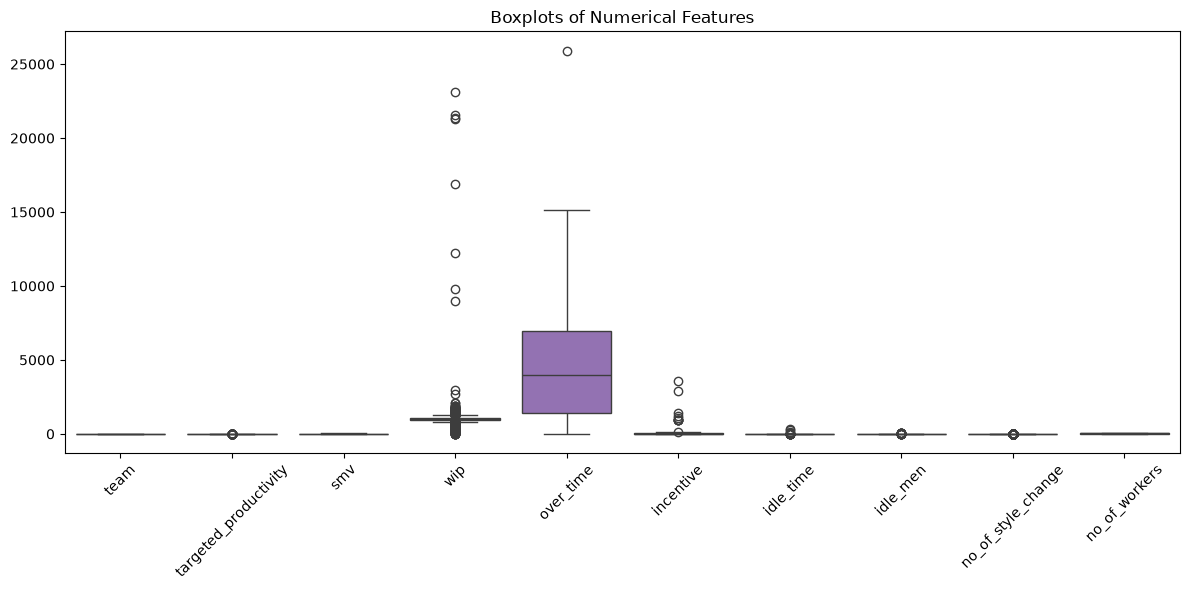

In [18]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_clean[numeric_features])

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
Q1 = df_clean["actual_productivity"].quantile(0.25)
Q3 = df_clean["actual_productivity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

target_outliers = df_clean[
    (df_clean["actual_productivity"] < lower_bound) |
    (df_clean["actual_productivity"] > upper_bound)
]

print("Number of target outliers:", len(target_outliers))
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Number of target outliers: 54
Lower bound: 0.35038907
Upper bound: 1.150170598


In [20]:
df_clean["overtime_per_worker"] = (
    df_clean["over_time"] /
    df_clean["no_of_workers"].replace(0, np.nan)
)

df_clean["overtime_per_worker"] = (
    df_clean["overtime_per_worker"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("New feature created: overtime_per_worker")

display(
    df_clean[
        ["over_time", "no_of_workers", "overtime_per_worker"]
    ].head()
)

New feature created: overtime_per_worker


,over_time,no_of_workers,overtime_per_worker
0,7080,59.0,120.000000
1,960,8.0,120.000000
2,3660,30.5,120.000000
3,3660,30.5,120.000000
4,1920,56.0,34.285714


In [21]:
X = df_clean.drop(columns=["actual_productivity"])
y = df_clean["actual_productivity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1197, 15)
y shape: (1197,)


In [22]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'overtime_per_worker']

Categorical features:
['date', 'quarter', 'department', 'day']


C:\Users\krish\AppData\Local\Temp\ipykernel_26092\486109433.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (957, 15)
Testing data: (240, 15)


In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [25]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

linear_r2 = r2_score(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_mae = mean_absolute_error(y_test, linear_pred)

print("Linear Regression")
print("-----------------")
print("R²   :", linear_r2)
print("RMSE :", linear_rmse)
print("MAE  :", linear_mae)

Linear Regression
-----------------
R²   : 0.15033229863910635
RMSE : 0.1502024407144791
MAE  : 0.11153730053415711


In [26]:
results = []

results.append({
    "Model": "Linear Regression",
    "R2": linear_r2,
    "RMSE": linear_rmse,
    "MAE": linear_mae
})

display(pd.DataFrame(results))

,Model,R2,RMSE,MAE
0,Linear Regression,0.150332,0.150202,0.111537


In [29]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

ridge_params = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

ridge_pred = ridge_grid.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)

print("Best Ridge parameters:")
print(ridge_grid.best_params_)

print("\nRidge Regression")
print("----------------")
print("R²   :", ridge_r2)
print("RMSE :", ridge_rmse)
print("MAE  :", ridge_mae)

Best Ridge parameters:
{'model__alpha': 10}

Ridge Regression
----------------
R²   : 0.17391487637267944
RMSE : 0.14810333416495133
MAE  : 0.10845558112493352


In [30]:
results.append({
    "Model": "Ridge Regression",
    "R2": ridge_r2,
    "RMSE": ridge_rmse,
    "MAE": ridge_mae
})

display(pd.DataFrame(results))

,Model,R2,RMSE,MAE
0,Linear Regression,0.150332,0.150202,0.111537
1,Ridge Regression,0.173915,0.148103,0.108456


In [31]:
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=10000))
    ]
)

lasso_params = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

lasso_pred = lasso_grid.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae = mean_absolute_error(y_test, lasso_pred)

print("Best Lasso parameters:")
print(lasso_grid.best_params_)

print("\nLasso Regression")
print("----------------")
print("R²   :", lasso_r2)
print("RMSE :", lasso_rmse)
print("MAE  :", lasso_mae)

Best Lasso parameters:
{'model__alpha': 0.001}

Lasso Regression
----------------
R²   : 0.18956866387205917
RMSE : 0.14669339086076813
MAE  : 0.10683214249826373


In [32]:
lasso_model = lasso_grid.best_estimator_.named_steps["model"]

zero_coefficients = np.sum(
    lasso_model.coef_ == 0
)

total_coefficients = len(lasso_model.coef_)

print("Total coefficients:", total_coefficients)
print("Zero coefficients:", zero_coefficients)
print(
    "Sparsity:",
    round(zero_coefficients / total_coefficients * 100, 2),
    "%"
)

Total coefficients: 84
Zero coefficients: 63
Sparsity: 75.0 %


In [33]:
results.append({
    "Model": "Lasso Regression",
    "R2": lasso_r2,
    "RMSE": lasso_rmse,
    "MAE": lasso_mae
})

display(pd.DataFrame(results))

,Model,R2,RMSE,MAE
0,Linear Regression,0.150332,0.150202,0.111537
1,Ridge Regression,0.173915,0.148103,0.108456
2,Lasso Regression,0.189569,0.146693,0.106832


In [34]:
elastic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", ElasticNet(max_iter=10000))
    ]
)

elastic_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    elastic_pipeline,
    elastic_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

elastic_grid.fit(X_train, y_train)

elastic_pred = elastic_grid.predict(X_test)

elastic_r2 = r2_score(y_test, elastic_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_test, elastic_pred))
elastic_mae = mean_absolute_error(y_test, elastic_pred)

print("Best ElasticNet parameters:")
print(elastic_grid.best_params_)

print("\nElasticNet Regression")
print("--------------------")
print("R²   :", elastic_r2)
print("RMSE :", elastic_rmse)
print("MAE  :", elastic_mae)

Best ElasticNet parameters:
{'model__alpha': 0.001, 'model__l1_ratio': 0.9}

ElasticNet Regression
--------------------
R²   : 0.1899081389518048
RMSE : 0.14666266403396447
MAE  : 0.10671257406085166


In [35]:
results.append({
    "Model": "ElasticNet Regression",
    "R2": elastic_r2,
    "RMSE": elastic_rmse,
    "MAE": elastic_mae
})

display(pd.DataFrame(results))

,Model,R2,RMSE,MAE
0,Linear Regression,0.150332,0.150202,0.111537
1,Ridge Regression,0.173915,0.148103,0.108456
2,Lasso Regression,0.189569,0.146693,0.106832
3,ElasticNet Regression,0.189908,0.146663,0.106713
